# Figure 2 and S4: DASIT iRFP Distribution - mod/DNA/Lenti


**Load in packages**

In [106]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
import scipy
from matplotlib.patches import Patch

## Load data

In [107]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.07.31_iRFP_lenti': ['Plate1', 'Plate2'], #Lenti and modRNA
        '2026.07.02_exp61': ['Plate2'], #Plasmid-1-2
        '2026.07.02_exp60': ['Plate1', 'Plate2'], #Plasmid-3-4
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata2.yaml')

output_path = rd.rootdir/'output'/'Figure_2_selectivity'
cache_path = rd.rootdir/'output'/'Figure_2_selectivity'/'data_iRFP.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
4,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [108]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


**Untransfected data**

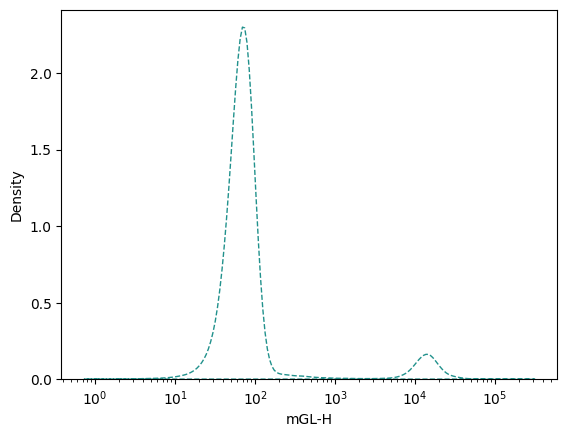

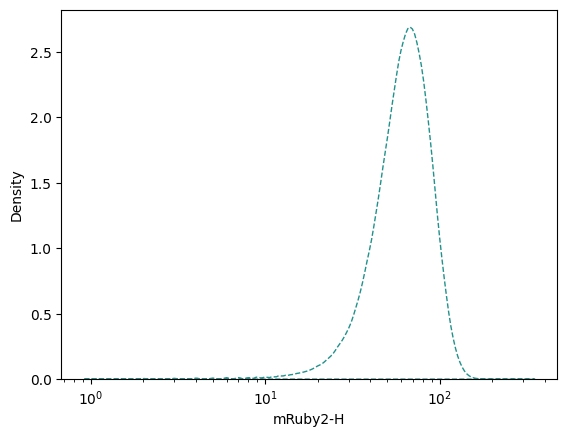

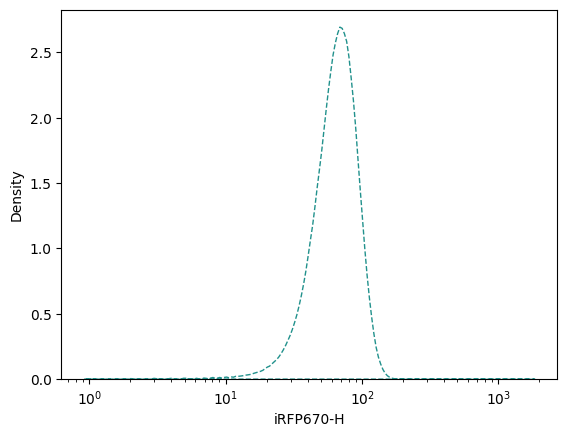

In [110]:
parameters = np.array(['mGL-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['reporter'] == 'Untransfected')& (data[param] > 0)]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [114]:
data['conds'] = data['reporter'] +'.'+ data['Deliver'] 
display(data)

,reporter,Puro,Puro#,Deliver,Plasmid,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,conds
0,pKG05002,0x,0,Lenti,1x,2026.07.31.x,A1,Single Cells,463729,147787,-22,65,107,99,-3,47,pKG05002.Lenti
1,pKG05002,0x,0,Lenti,1x,2026.07.31.x,A1,Single Cells,486842,197250,-38,54,28540,20456,-86,61,pKG05002.Lenti
2,pKG05002,0x,0,Lenti,1x,2026.07.31.x,A1,Single Cells,569925,233442,146,92,-105,33,-62,55,pKG05002.Lenti
3,pKG05002,0x,0,Lenti,1x,2026.07.31.x,A1,Single Cells,448998,420921,38,86,20569,13485,11,88,pKG05002.Lenti
4,pKG05002,0x,0,Lenti,1x,2026.07.31.x,A1,Single Cells,534490,342837,-39,85,3166,2157,-63,74,pKG05002.Lenti
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14156400,pKG05003,0x,0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,298796,138615,-14,50,49,109,88,88,pKG05003.Plasmid
14156401,pKG05003,0x,0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,165894,176331,81,103,-59,64,-15,46,pKG05003.Plasmid
14156402,pKG05003,0x,0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,350031,282455,101,103,53,74,22,81,pKG05003.Plasmid
14156403,pKG05003,0x,0,Plasmid,0.1x,2026.07.02.xx,H9,Single Cells,451891,245852,-15,32,-80,31,-157,24,pKG05003.Plasmid


In [121]:
ctrl_data = data[data['reporter'] == 'Untransfected'].copy()

## Figure 2D histogram

**Figure 2D histogram**

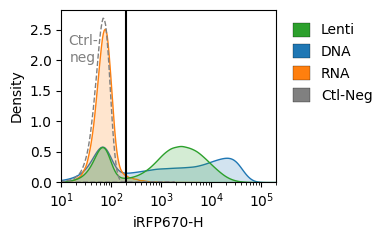

In [144]:
order = ['pKG05003.Lenti', 'pKG05003.Plasmid', 'pKG05000.Mod']

label_map = {
    'pKG05003.Lenti':'Lenti',
    'pKG05003.Plasmid':'DNA',
    'pKG05000.Mod': 'RNA',
    'Untransfected.Plasmid': 'Ctl-Neg'
}
untransfected = data[(data['conds'] == 'Untransfected.Plasmid') & (data['iRFP670-H'] > 0) & (data['Plasmid'] == '0x')]
data_new = data[(data['conds'].isin(order)) & (data['iRFP670-H'] > 0)& (data['Plasmid'] == '1x') & (data['Puro'] == '0x')]

g = plt.figure(figsize=(4,2.5))
palette = {'Untransfected.Plasmid': 'grey',
        'pKG05003.Lenti': 'tab:green',
        'pKG05000.Mod': 'tab:orange',
        'pKG05003.Plasmid': 'tab:blue'}
ax = sns.kdeplot(data_new, x='iRFP670-H',hue='conds',log_scale=(True,False),legend=False,fill=True,common_norm=False,palette=palette, alpha = 0.2)
sns.kdeplot(untransfected, x='iRFP670-H',hue='conds',log_scale=(True,False),legend=False,fill=True,common_norm=False,palette=palette, alpha = 0, linestyle = '--')
ax.axvline(x = 200, color='black', linestyle='-')
ax.annotate('Ctrl-\nneg', (0.1, 0.7), color='grey', xycoords='axes fraction', ha='center')

legend_handles = [
    Patch(
        facecolor=palette[c],
        edgecolor='black',
        label=label_map[c], linewidth = 0.2
    )
    for c in order
]

legend_handles.append(
    Patch(
        facecolor='grey',
        edgecolor='black',
        label='Ctl-Neg',linewidth = 0.2
    )
)

ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    title='',
    handleheight = 1.2,
    handlelength = 1.2
)

# Adjust limits
iRFP_lim = (10, 2*10**5)
for sub_ax in plt.gcf().get_axes():
    sub_ax.set_xlim(iRFP_lim)

g.tight_layout()
g = g.get_figure()
plottitle = 'iRFP670_histogram.svg'
g.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Summary plot code

In [116]:
# Remove conditions from selection experiments and titration experiments
data_subset = data[(data['Plasmid'] == '1x') & (data['Puro'] == '0x')].copy()

**Setting iRFP670_cat and counting infected cells**

In [117]:
iRFP670_H_thresh = 2.5e2
# Categorize cells based on iRFP670_thresh
data_subset.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data_subset.loc[(data['iRFP670-H'] > iRFP670_H_thresh), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'reporter', 'conds', 'Date','Deliver','Plasmid','Puro']
count_df_reps = data_subset.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no iRFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

In [118]:
df_infected = data_subset[data_subset['iRFP670_cat'] == 'iRFP670+'].copy()

**Pull out only wtNB conditions**

In [119]:
order = ['pKG05003', 'pKG05000']
df_infected_subset = df_infected[(df_infected['reporter'].isin(order))].copy()
df_infected_subset

,reporter,Puro,Puro#,Deliver,Plasmid,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,conds,iRFP670_cat
298671,pKG05003,0x,0,Lenti,1x,2026.07.31.x,A4,Single Cells,477506,226179,52,85,7984,5971,1151,725,pKG05003.Lenti,iRFP670+
298672,pKG05003,0x,0,Lenti,1x,2026.07.31.x,A4,Single Cells,388068,168871,15,65,1957,1638,468,316,pKG05003.Lenti,iRFP670+
298673,pKG05003,0x,0,Lenti,1x,2026.07.31.x,A4,Single Cells,297924,166461,-83,42,966,848,-49,55,pKG05003.Lenti,iRFP670+
298675,pKG05003,0x,0,Lenti,1x,2026.07.31.x,A4,Single Cells,367255,137628,17755,13332,2788,2277,453,413,pKG05003.Lenti,iRFP670+
298676,pKG05003,0x,0,Lenti,1x,2026.07.31.x,A4,Single Cells,321584,172027,1396,1167,1133,975,148,108,pKG05003.Lenti,iRFP670+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13300914,pKG05003,0x,0,Plasmid,1x,2026.07.02.xx,F9,Single Cells,376023,214046,112,70,990,801,-34,36,pKG05003.Plasmid,iRFP670+
13300918,pKG05003,0x,0,Plasmid,1x,2026.07.02.xx,F9,Single Cells,371576,229563,122,91,385,308,-90,47,pKG05003.Plasmid,iRFP670+
13300921,pKG05003,0x,0,Plasmid,1x,2026.07.02.xx,F9,Single Cells,379357,242618,34,82,10547,9038,7446,5794,pKG05003.Plasmid,iRFP670+
13300925,pKG05003,0x,0,Plasmid,1x,2026.07.02.xx,F9,Single Cells,362260,228024,201,94,1062,973,-12,70,pKG05003.Plasmid,iRFP670+


In [87]:
display(
    df_infected_subset.groupby('conds')['Date'].unique()
)

conds
pKG05000.Mod        [2026.07.31.xxx, 2026.07.31.x, 2026.07.31.xx]
pKG05003.Lenti      [2026.07.31.x, 2026.07.31.xx, 2026.07.31.xxx]
pKG05003.Plasmid     [2026.07.02.bb, 2026.07.02.x, 2026.07.02.xx]
Name: Date, dtype: object

In [127]:
y = 'iRFP670-H'
group = ['conds', 'reporter', 'Date','Deliver']

df_gmean = (
    df_infected_subset[df_infected_subset[y]>0]
    .groupby(group)[y]
    .agg(**{y + ' (gmean)': scipy.stats.gmean})
    .reset_index()
)

df_ctrl_gmean = (
    ctrl_data[ctrl_data[y] > 0]
    .groupby(group)[y]
    .agg(**{y + ' (gmean)': scipy.stats.gmean})
    .reset_index()
)

df_gmean_final = pd.concat([df_gmean, df_ctrl_gmean], ignore_index=True)

In [128]:
df_gmean_final

,conds,reporter,Date,Deliver,iRFP670-H (gmean)
0,pKG05000.Mod,pKG05000,2026.07.31.x,Mod,390.602394
1,pKG05000.Mod,pKG05000,2026.07.31.xx,Mod,354.903508
2,pKG05000.Mod,pKG05000,2026.07.31.xxx,Mod,400.078933
3,pKG05003.Lenti,pKG05003,2026.07.31.x,Lenti,2543.595061
4,pKG05003.Lenti,pKG05003,2026.07.31.xx,Lenti,2566.377182
5,pKG05003.Lenti,pKG05003,2026.07.31.xxx,Lenti,2649.577058
6,pKG05003.Plasmid,pKG05003,2026.07.02.bb,Plasmid,4022.857479
7,pKG05003.Plasmid,pKG05003,2026.07.02.x,Plasmid,5991.490900
8,pKG05003.Plasmid,pKG05003,2026.07.02.xx,Plasmid,4701.152803
9,Untransfected.Plasmid,Untransfected,2026.07.02.x,Plasmid,61.939568


## Figure S4B plot

**Figure S4B summary plot**

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_42772\3574217092.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

pKG05003.Plasmid vs. pKG05000.Mod: t-test independent samples with Bonferroni correction, P_val:2.870e-03 t=7.832e+00
pKG05003.Plasmid vs. pKG05003.Lenti: t-test independent samples with Bonferroni correction, P_val:3.200e-02 t=4.010e+00


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_42772\3574217092.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


,count,mean,std,min,25%,50%,75%,max
conds,,,,,,,,
pKG05000.Mod,3.0,381.861612,23.822379,354.903508,372.752951,390.602394,395.340664,400.078933
pKG05003.Lenti,3.0,2586.516434,55.787436,2543.595061,2554.986121,2566.377182,2607.977120,2649.577058
pKG05003.Plasmid,3.0,4905.167060,1000.047873,4022.857479,4362.005141,4701.152803,5346.321851,5991.490900


                                                  iRFP670-H (gmean)
conds            reporter Date           Deliver                   
pKG05000.Mod     pKG05000 2026.07.31.x   Mod             390.602394
                          2026.07.31.xx  Mod             354.903508
                          2026.07.31.xxx Mod             400.078933
pKG05003.Lenti   pKG05003 2026.07.31.x   Lenti          2543.595061
                          2026.07.31.xx  Lenti          2566.377182
                          2026.07.31.xxx Lenti          2649.577058
pKG05003.Plasmid pKG05003 2026.07.02.bb  Plasmid        4022.857479
                          2026.07.02.x   Plasmid        5991.490900
                          2026.07.02.xx  Plasmid        4701.152803


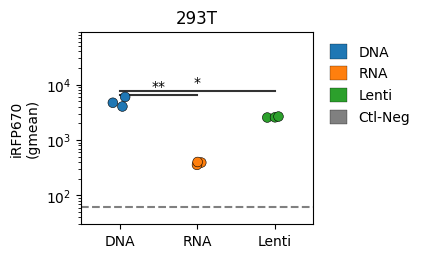

In [145]:
# Plotting params
x = 'conds'
y = 'iRFP670-H'
order = ['pKG05003.Plasmid','pKG05000.Mod','pKG05003.Lenti']

label_map = {
    'pKG05003.Lenti':'Lenti',
    'pKG05003.Plasmid':'DNA',
    'pKG05000.Mod': 'RNA',
    'Untransfected.Plasmid': 'Ctl-Neg'
}

data_new = df_gmean[(df_gmean['conds'].isin(order))]

palette = {'Untransfected.Plasmid': 'grey',
        'pKG05003.Lenti': 'tab:green',
        'pKG05000.Mod': 'tab:orange',
        'pKG05003.Plasmid': 'tab:blue'}

# Conditions
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

# Plot geometric means
sns.stripplot(
    ax=ax, data=data_new,
    x=x, y=y+' (gmean)',
    order=order,
    palette=palette,
    dodge=False, 
    size=7,
    edgecolor='black', linewidth=0.4)

# Plot ctrl-neg
ax.axhline(float(df_gmean_final.loc[df_gmean_final.conds == 'Untransfected.Plasmid', y+' (gmean)'].iloc[0]), 0, 1, color='grey', linestyle='--')

# # Add in stats
# # Pairs for stats comp
pairs = [('pKG05003.Plasmid', 'pKG05003.Lenti'),
         ('pKG05003.Plasmid', 'pKG05000.Mod')]
annot = Annotator(ax=ax,
    data=data_new, pairs=pairs,
    x=x, y=y+' (gmean)',
    order=order)

annot.configure(
    test='t-test_ind',
    comparisons_correction='Bonferroni',
    text_format='star',
    loc='outside',
    verbose=2
)

annot.apply_test().annotate()


# # Adjust labels
ax.set_xticklabels([label_map[l] for l in order])
ax.set_xlabel('')
# ax.ticklabel_format(axis='y', style='sci', scilimits=(1, 2))
ax.set_yscale('log')
ax.set_ylim((3e1, 9e4))
ax.yaxis.set_label_text('iRFP670\n(gmean)')


legend_handles = [
    Patch(
        facecolor=palette[c],
        edgecolor='black',
        label=label_map[c], linewidth = 0.2
    )
    for c in order
]

legend_handles.append(
    Patch(
        facecolor='grey',
        edgecolor='black',
        label='Ctl-Neg',linewidth = 0.2
    )
)

ax.legend(
    handles=legend_handles,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    title='',
    handleheight = 1.2,
    handlelength = 1.2
)

plt.title('293T')

display(
    data_new.groupby('conds')[y+' (gmean)'].describe()
)

print(df_gmean.groupby(['conds', 'reporter', 'Date','Deliver']).mean())

plottitle = 'iRFP670_summary_plot.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


**Calculating fold change between modalities**

In [146]:
means = (
    df_gmean
    .groupby('Deliver')['iRFP670-H (gmean)']
    .mean()
)

fold_plasmid_lenti = means['Plasmid'] / means['Lenti']
fold_plasmid_mod = means['Plasmid'] / means['Mod']

print(f'Plasmid vs Lenti: {fold_plasmid_lenti:.2f}-fold')
print(f'Plasmid vs Mod: {fold_plasmid_mod:.2f}-fold')

Plasmid vs Lenti: 1.90-fold
Plasmid vs Mod: 12.85-fold
